In [1]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [2]:
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)


Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [3]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
EXCEL_PATH      = '/content/drive/MyDrive/Clinical_and_Other_Features.xlsx'
TEXT_CSV        = '/content/drive/MyDrive/llama_patient_radiology_reports.csv'

ID_COL          = 'Patient ID'
LABEL_COL       = 'Mol Subtype'

BATCH_SIZE      = 16      # Text-only is much lighter — can use larger batch
EPOCHS          = 50
LEARNING_RATE_TEXT = 2e-5   # BiomedBERT LR — low since already pretrained
LEARNING_RATE_HEAD = 5e-4   # Classification head LR
MAX_TEXT_LEN    = 256
PATIENCE        = 8
GRAD_CLIP       = 1.0

TEXT_MODEL_NAME = "microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"Text encoder: {TEXT_MODEL_NAME}")
print("Model: Text Only — BiomedBERT + MLP head")


Device: cuda
Text encoder: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext
Model: Text Only — BiomedBERT + MLP head


In [4]:
# ==========================================
# 2. LOAD TOKENIZER & REPORTS
# ==========================================
print(f"Loading tokenizer: {TEXT_MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL_NAME)

text_df = pd.read_csv(TEXT_CSV)
text_df['patient_id'] = text_df['patient_id'].astype(str)
text_dict = dict(zip(text_df['patient_id'], text_df['generated_report']))
print(f"Loaded {len(text_dict)} radiology reports")


Loading tokenizer: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Loaded 922 radiology reports


In [5]:
# ==========================================
# 3. DATASET  –  Text only
# ==========================================
class TextOnlyDataset(Dataset):
    def __init__(self, df, text_dict, tokenizer, max_len=256):
        self.df        = df.reset_index(drop=True)
        self.text_dict = text_dict
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row        = self.df.loc[idx]
        patient_id = str(row[ID_COL]).strip()
        label      = row['encoded_label']

        text = self.text_dict.get(patient_id, "")
        if not isinstance(text, str) or not text:
            text = "No report available."

        tokens = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )

        return (
            tokens['input_ids'].squeeze(0),
            tokens['attention_mask'].squeeze(0),
            torch.tensor(label, dtype=torch.long)
        )


In [6]:
# ==========================================
# 4. FOCAL LOSS WITH LABEL SMOOTHING
# ==========================================
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.1, reduction='mean'):
        super().__init__()
        self.weight          = weight
        self.gamma           = gamma
        self.label_smoothing = label_smoothing
        self.reduction       = reduction

    def forward(self, inputs, targets):
        num_classes  = inputs.size(1)
        smooth_val   = self.label_smoothing / (num_classes - 1)
        soft_targets = torch.full_like(inputs, smooth_val)
        soft_targets.scatter_(1, targets.unsqueeze(1), 1.0 - self.label_smoothing)

        ce_loss    = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        pt         = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean': return focal_loss.mean()
        elif self.reduction == 'sum': return focal_loss.sum()
        return focal_loss


In [7]:
# ==========================================
# 5. SETUP & SPLITS  (same 70/15/15 as multimodal)
# ==========================================
print("Loading clinical data...")
df = pd.read_excel(EXCEL_PATH, header=1)
df[ID_COL] = df[ID_COL].astype(str)
df = df.dropna(subset=[LABEL_COL, ID_COL])

# Keep only patients that have a radiology report
df = df[df[ID_COL].isin(text_dict.keys())].copy().reset_index(drop=True)
print(f"Total usable subjects (with reports): {len(df)}")

le = LabelEncoder()
df['encoded_label'] = le.fit_transform(df[LABEL_COL])
num_classes = len(le.classes_)
print(f"Classes ({num_classes}): {list(le.classes_)}")

print("\nClass distribution:")
print(df[LABEL_COL].value_counts())

# 70 / 15 / 15 split — same random_state as multimodal for fair comparison
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['encoded_label'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['encoded_label'], random_state=42
)
print(f"\nSplits -> Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

classes       = np.unique(train_df['encoded_label'])
weights       = compute_class_weight('balanced', classes=classes, y=train_df['encoded_label'])
class_weights = torch.tensor(weights, dtype=torch.float).to(device)
print(f"Class weights: {dict(zip(le.classes_, weights.round(3)))}")


Loading clinical data...
Total usable subjects (with reports): 922
Classes (4): [0, 1, 2, 3]

Class distribution:
Mol Subtype
0    595
3    164
1    104
2     59
Name: count, dtype: int64

Splits -> Train: 645 | Val: 138 | Test: 139
Class weights: {0: np.float64(0.388), 1: np.float64(2.209), 2: np.float64(3.933), 3: np.float64(1.402)}


In [8]:
# ==========================================
# 6. DATALOADERS
# ==========================================
train_dataset = TextOnlyDataset(train_df, text_dict, tokenizer, MAX_TEXT_LEN)
val_dataset   = TextOnlyDataset(val_df,   text_dict, tokenizer, MAX_TEXT_LEN)
test_dataset  = TextOnlyDataset(test_df,  text_dict, tokenizer, MAX_TEXT_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")


Train batches: 41 | Val batches: 9


In [9]:
# ==========================================
# 7. MODEL ARCHITECTURE  –  BiomedBERT text only
#    Same BiomedBERT encoder as multimodal model.
#    Same 2-layer MLP head for fair comparison.
#    No image input at all.
# ==========================================
def mean_pool(last_hidden_state, attention_mask):
    mask   = attention_mask.unsqueeze(-1).float()
    summed = (last_hidden_state * mask).sum(dim=1)
    count  = mask.sum(dim=1).clamp(min=1e-9)
    return summed / count


class TextOnlyModel(nn.Module):
    def __init__(self, num_classes, text_model_name=TEXT_MODEL_NAME):
        super().__init__()

        # BiomedBERT encoder  (same as multimodal)
        self.text_encoder = AutoModel.from_pretrained(text_model_name)
        text_dim = self.text_encoder.config.hidden_size   # 768

        # 2-layer MLP head  (mirrors FusionMLP for fair comparison)
        self.head = nn.Sequential(
            nn.Linear(text_dim, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        text_out  = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        text_feat = mean_pool(text_out.last_hidden_state, attention_mask)   # (B, 768)
        return self.head(text_feat)


model = TextOnlyModel(num_classes=num_classes).to(device)
print(f"Model: BiomedBERT Text Only")
print(f"Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model: BiomedBERT Text Only
Parameters: 110,009,860


In [10]:
# ==========================================
# 8. TRAINING SETUP
# ==========================================
criterion = FocalLoss(weight=class_weights, gamma=2.0, label_smoothing=0.1)

optimizer = optim.AdamW([
    {'params': model.text_encoder.parameters(), 'lr': LEARNING_RATE_TEXT},
    {'params': model.head.parameters(),         'lr': LEARNING_RATE_HEAD},
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
scaler    = torch.amp.GradScaler('cuda')


In [11]:
# ==========================================
# 9. TRAINING LOOP WITH EARLY STOPPING
# ==========================================
print("\nStarting Training...")

BEST_CKPT_PATH = '/content/drive/MyDrive/llama_biomedbert_best.pth'

history = {'train_loss': [], 'val_acc': [], 'val_auc': []}

best_combined    = 0.0
best_val_auc     = 0.0
best_val_acc     = 0.0
best_epoch       = 0
best_preds       = []
best_labels_list = []
best_probs       = []
patience_count   = 0
best_model_state = None

for epoch in range(EPOCHS):
    # ---- TRAIN ----
    model.train()
    running_loss = 0.0

    for input_ids, attention_mask, labels in train_loader:
        input_ids      = input_ids.to(device, non_blocking=True)
        attention_mask = attention_mask.to(device, non_blocking=True)
        labels         = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            outputs = model(input_ids, attention_mask)
            loss    = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * input_ids.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    scheduler.step()

    # ---- VALIDATE ----
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for input_ids, attention_mask, labels in val_loader:
            input_ids      = input_ids.to(device, non_blocking=True)
            attention_mask = attention_mask.to(device, non_blocking=True)

            with torch.amp.autocast('cuda'):
                outputs = model(input_ids, attention_mask)
                probs   = F.softmax(outputs, dim=1)

            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    try:
        if num_classes > 2:
            auc_score = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
        else:
            auc_score = roc_auc_score(all_labels, np.array(all_probs)[:, 1])
    except ValueError:
        auc_score = 0.0

    combined_score = 0.5 * auc_score + 0.5 * acc
    current_lr     = optimizer.param_groups[0]['lr']

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] Loss: {epoch_loss:.4f} | "
          f"Val Acc: {acc:.4f} | Val AUC: {auc_score:.4f} | "
          f"Combined: {combined_score:.4f} | LR: {current_lr:.2e}")

    history['train_loss'].append(epoch_loss)
    history['val_acc'].append(acc)
    history['val_auc'].append(auc_score)

    # ── Save best checkpoint ──────────────────────────────────────────────
    if combined_score > best_combined:
        best_combined    = combined_score
        best_val_auc     = auc_score
        best_val_acc     = acc
        best_epoch       = epoch + 1
        best_preds       = all_preds.copy()
        best_labels_list = all_labels.copy()
        best_probs       = all_probs.copy()
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_count   = 0

        torch.save({
            'epoch'           : best_epoch,
            'model_state_dict': best_model_state,
            'val_auc'         : best_val_auc,
            'val_acc'         : best_val_acc,
            'combined_score'  : best_combined,
            'num_classes'     : num_classes,
            'le_classes'      : le.classes_.tolist(),
            'MAX_TEXT_LEN'    : MAX_TEXT_LEN,
            'TEXT_MODEL_NAME' : TEXT_MODEL_NAME,
            'history'         : history,
        }, BEST_CKPT_PATH)

        print(f"  ✓ New best  AUC: {auc_score:.4f} | Acc: {acc:.4f} | "
              f"Combined: {combined_score:.4f} — saved to Drive")
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"  Early stopping at epoch {epoch+1} "
                  f"(no improvement for {PATIENCE} epochs)")
            break

# ── Restore best weights ──────────────────────────────────────────────────
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"\nRestored best model (epoch {best_epoch})")

print("\n" + "="*55)
print(f"BEST CHECKPOINT  (epoch {best_epoch})")
print("="*55)
print(f"  Val Accuracy   : {best_val_acc:.4f}")
print(f"  Val Macro AUC  : {best_val_auc:.4f}")
print(f"  Combined Score : {best_combined:.4f}  (0.5xAUC + 0.5xAcc)")
print(f"  Saved to       : {BEST_CKPT_PATH}")
print("="*55)

all_preds  = best_preds
all_labels = best_labels_list
all_probs  = best_probs



Starting Training...


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Epoch [01/50] Loss: 1.0180 | Val Acc: 0.1377 | Val AUC: 0.4996 | Combined: 0.3186 | LR: 2.00e-05
  ✓ New best  AUC: 0.4996 | Acc: 0.1377 | Combined: 0.3186 — saved to Drive
Epoch [02/50] Loss: 0.9581 | Val Acc: 0.1667 | Val AUC: 0.5107 | Combined: 0.3387 | LR: 1.99e-05
  ✓ New best  AUC: 0.5107 | Acc: 0.1667 | Combined: 0.3387 — saved to Drive
Epoch [03/50] Loss: 0.9266 | Val Acc: 0.1377 | Val AUC: 0.5420 | Combined: 0.3398 | LR: 1.98e-05
  ✓ New best  AUC: 0.5420 | Acc: 0.1377 | Combined: 0.3398 — saved to Drive
Epoch [04/50] Loss: 0.8838 | Val Acc: 0.1377 | Val AUC: 0.5186 | Combined: 0.3281 | LR: 1.97e-05
Epoch [05/50] Loss: 0.8795 | Val Acc: 0.1739 | Val AUC: 0.5167 | Combined: 0.3453 | LR: 1.95e-05
  ✓ New best  AUC: 0.5167 | Acc: 0.1739 | Combined: 0.3453 — saved to Drive
Epoch [06/50] Loss: 0.8381 | Val Acc: 0.1159 | Val AUC: 0.4842 | Combined: 0.3001 | LR: 1.93e-05
Epoch [07/50] Loss: 0.7400 | Val Acc: 0.1159 | Val AUC: 0.4699 | Combined: 0.2929 | LR: 1.91e-05
Epoch [08/50] Los

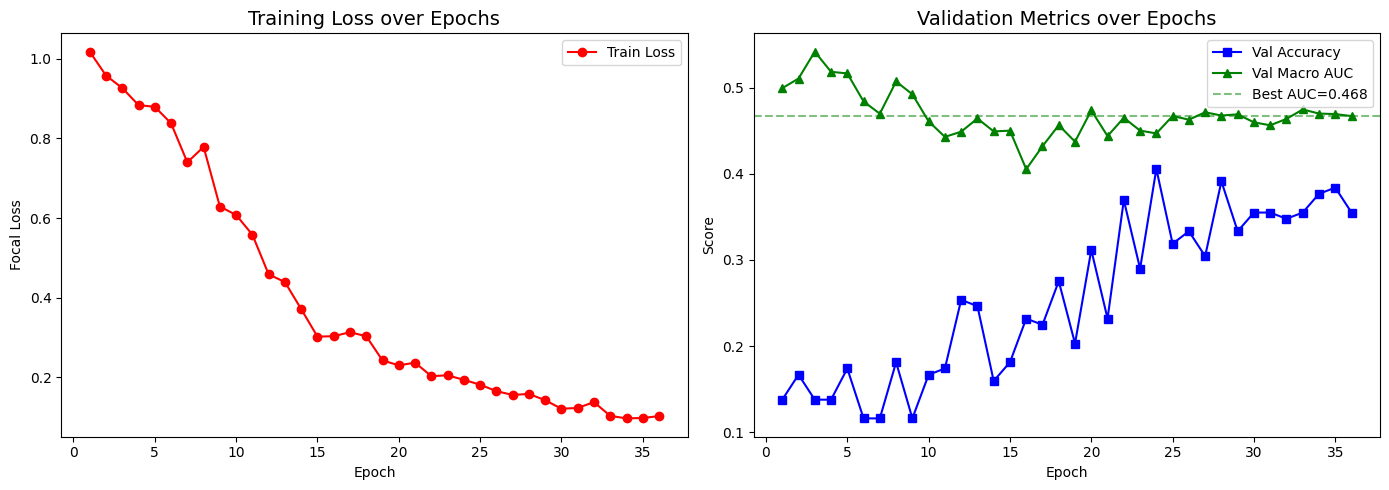

In [12]:
# ==========================================
# 10. LEARNING CURVES
# ==========================================
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(history['train_loss'])+1), history['train_loss'],
         marker='o', color='red', label='Train Loss')
plt.title('Training Loss over Epochs', fontsize=14)
plt.xlabel('Epoch'); plt.ylabel('Focal Loss'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(history['val_acc'])+1), history['val_acc'],
         marker='s', color='blue',  label='Val Accuracy')
plt.plot(range(1, len(history['val_auc'])+1), history['val_auc'],
         marker='^', color='green', label='Val Macro AUC')
plt.axhline(best_val_auc, color='green', linestyle='--', alpha=0.5,
            label=f'Best AUC={best_val_auc:.3f}')
plt.title('Validation Metrics over Epochs', fontsize=14)
plt.xlabel('Epoch'); plt.ylabel('Score'); plt.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/textonly_learning_curves.png', dpi=150)
plt.show()


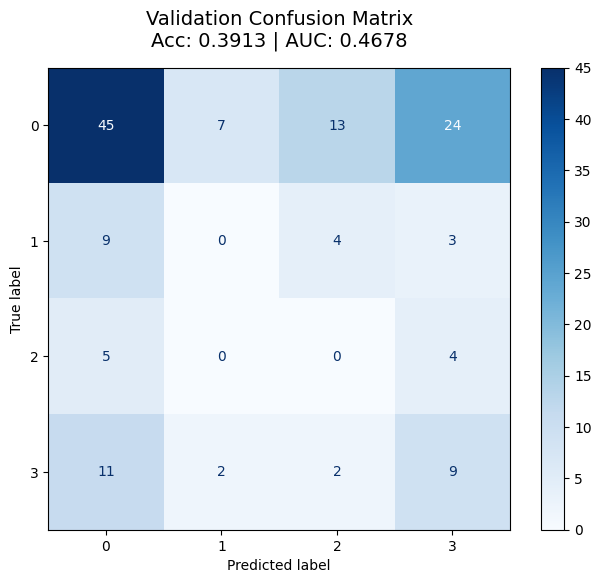

In [13]:
# ==========================================
# 11. CONFUSION MATRIX (Validation)
# ==========================================
cm         = confusion_matrix(all_labels, all_preds, labels=range(num_classes))
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
cm_display.plot(ax=ax, cmap='Blues', colorbar=True)
ax.grid(False)
plt.title(f'Validation Confusion Matrix\nAcc: {best_val_acc:.4f} | AUC: {best_val_auc:.4f}',
          fontsize=14, pad=15)
plt.savefig('/content/drive/MyDrive/textonly_val_confusion_matrix.png', dpi=150)
plt.show()



EVALUATION ON UNSEEN TEST DATA
FINAL TEST ACCURACY : 0.4173
FINAL TEST MACRO AUC: 0.4491



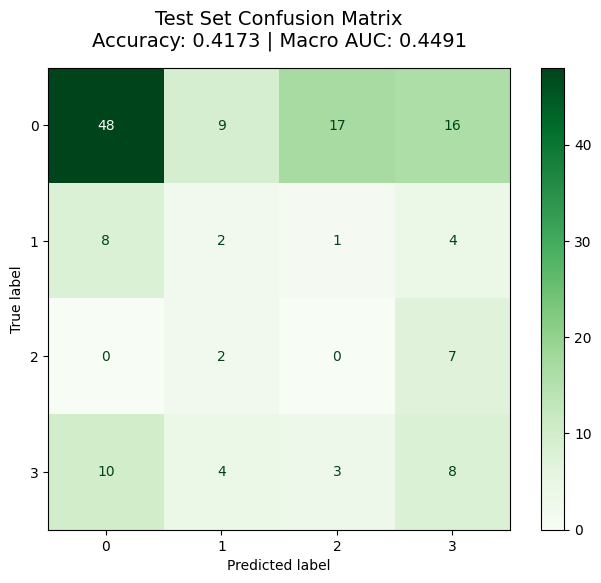

In [14]:
# ==========================================
# 12. FINAL TEST EVALUATION
# ==========================================
print("\n" + "="*50)
print("EVALUATION ON UNSEEN TEST DATA")
print("="*50)

model.eval()
test_preds, test_labels, test_probs = [], [], []

with torch.no_grad():
    for input_ids, attention_mask, labels in test_loader:
        input_ids      = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        with torch.amp.autocast('cuda'):
            outputs = model(input_ids, attention_mask)
            probs   = F.softmax(outputs, dim=1)

        _, preds = torch.max(outputs, 1)
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.numpy())
        test_probs.extend(probs.cpu().numpy())

test_acc = accuracy_score(test_labels, test_preds)
try:
    if num_classes > 2:
        test_auc = roc_auc_score(test_labels, test_probs, multi_class='ovr', average='macro')
    else:
        test_auc = roc_auc_score(test_labels, np.array(test_probs)[:, 1])
except ValueError:
    test_auc = 0.0

print(f"FINAL TEST ACCURACY : {test_acc:.4f}")
print(f"FINAL TEST MACRO AUC: {test_auc:.4f}\n")

test_cm    = confusion_matrix(test_labels, test_preds, labels=range(num_classes))
cm_display = ConfusionMatrixDisplay(confusion_matrix=test_cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
cm_display.plot(ax=ax, cmap='Greens', colorbar=True)
ax.grid(False)
plt.title(f'Test Set Confusion Matrix\nAccuracy: {test_acc:.4f} | Macro AUC: {test_auc:.4f}',
          fontsize=14, pad=15)
plt.savefig('/content/drive/MyDrive/textonly_test_confusion_matrix.png', dpi=150)
plt.show()


In [15]:
# ==========================================
# 13. PREDICTIONS FOR FIXED 10 PATIENTS
#     Same patients as GradCAM comparison
# ==========================================

FIXED_PATIENT_IDS = [
    'Breast_MRI_467', 'Breast_MRI_613', 'Breast_MRI_417',
    'Breast_MRI_504', 'Breast_MRI_335', 'Breast_MRI_420',
    'Breast_MRI_293', 'Breast_MRI_341', 'Breast_MRI_608',
    'Breast_MRI_216',
]

model.eval()
summary_rows = []

for patient_id in FIXED_PATIENT_IDS:
    # ── Get true label from df ────────────────────────────────────────────
    df_match = df[df[ID_COL] == patient_id]
    if len(df_match) > 0:
        true_label = int(df_match.iloc[0]['encoded_label'])
        true_name  = le.classes_[true_label]
    else:
        true_label = -1
        true_name  = 'Unknown'

    # ── Get text report ───────────────────────────────────────────────────
    text = text_dict.get(patient_id, "No report available.")
    if not isinstance(text, str) or not text:
        text = "No report available."

    # ── Tokenise ──────────────────────────────────────────────────────────
    tokens = tokenizer(
        text,
        padding='max_length',
        truncation=True,
        max_length=MAX_TEXT_LEN,
        return_tensors='pt'
    )
    input_ids      = tokens['input_ids'].to(device)
    attention_mask = tokens['attention_mask'].to(device)

    # ── Predict ───────────────────────────────────────────────────────────
    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            output = model(input_ids, attention_mask)
            probs  = F.softmax(output, dim=1)[0].cpu().numpy()

    pred_class = int(probs.argmax())
    pred_name  = le.classes_[pred_class]
    correct    = '✓' if true_label == pred_class else '✗'
    conf       = float(probs[pred_class])

    summary_rows.append({
        'Patient'   : patient_id,
        'True'      : true_name,
        'Pred'      : pred_name,
        'Correct'   : correct,
        'Confidence': f'{conf:.3f}',
        'All Probs' : {k: round(float(v), 3) for k, v in zip(le.classes_, probs)},
    })

# ── Print summary ─────────────────────────────────────────────────────────
print("\n" + "="*65)
print("PREDICTIONS  –  Text Only (BiomedBERT)")
print("="*65)
summary_df = pd.DataFrame(summary_rows).drop(columns=['All Probs'])
print(summary_df.to_string(index=False))
print("="*65)

# ── Per-patient detailed probs ────────────────────────────────────────────
print("\nDetailed probabilities per patient:")
for row in summary_rows:
    print(f"  {row['Patient']}  |  True: {row['True']}  |  "
          f"Pred: {row['Pred']} {row['Correct']}  |  "
          f"Probs: {row['All Probs']}")


PREDICTIONS  –  Text Only (BiomedBERT)
       Patient  True  Pred Correct Confidence
Breast_MRI_467     0     0       ✓      0.938
Breast_MRI_613     0     0       ✓      0.946
Breast_MRI_417     0     3       ✗      0.734
Breast_MRI_504     0     0       ✓      0.913
Breast_MRI_335     0     0       ✓      0.889
Breast_MRI_420     3     0       ✗      0.537
Breast_MRI_293     3     3       ✓      0.894
Breast_MRI_341     0     3       ✗      0.523
Breast_MRI_608     1     2       ✗      0.957
Breast_MRI_216     0     3       ✗      0.738

Detailed probabilities per patient:
  Breast_MRI_467  |  True: 0  |  Pred: 0 ✓  |  Probs: {0: 0.938, 1: 0.035, 2: 0.02, 3: 0.007}
  Breast_MRI_613  |  True: 0  |  Pred: 0 ✓  |  Probs: {0: 0.946, 1: 0.032, 2: 0.012, 3: 0.009}
  Breast_MRI_417  |  True: 0  |  Pred: 3 ✗  |  Probs: {0: 0.258, 1: 0.007, 2: 0.001, 3: 0.734}
  Breast_MRI_504  |  True: 0  |  Pred: 0 ✓  |  Probs: {0: 0.913, 1: 0.01, 2: 0.067, 3: 0.011}
  Breast_MRI_335  |  True: 0  |  Pred: 